In [1]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from catboost import cv, Pool
from sklearn import metrics


In [2]:
train = pd.read_csv("../artifacts/feature_engineering/features_train.csv")
test = pd.read_csv("../artifacts/feature_engineering/features_test.csv")

target = "log_price"

X_train = train.drop(columns=target)
y_train = train[target]

X_test = test.drop(columns=target)
y_test = test[target]


In [3]:
model = CatBoostRegressor(random_seed=2026)
model = model.fit(X_train, y_train, logging_level="Silent")

In [4]:
def get_cv_score(X, y, params):
    cv_params = params.copy()
    cv_params["eval_metric"] = "R2"

    cv_dataset = Pool(data=X, label=y)

    cv_results = cv(
        params=cv_params,
        pool=cv_dataset,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42,
        verbose=False,
    )

    target_col = [col for col in cv_results.columns if "test-R2-mean" in col]

    if not target_col:
        target_col = [
            col for col in cv_results.columns if "test-" in col and "-mean" in col
        ]
        print(f"R2 not found. Available metrics: {cv_results.columns.tolist()}")

    final_score = cv_results[target_col[0]].iloc[-1]

    return (
        round(final_score * 100, 2) if "R2" in target_col[0] else round(final_score, 4)
    )

In [5]:
def compute_catboost_metrics(model, x_test, y_test, x_train_full, y_train_full):
    preds = model.predict(x_test)
    r2 = metrics.r2_score(y_test, preds)

    params = model.get_params()
    cv_score = get_cv_score(x_train_full, y_train_full, params)

    return pd.DataFrame(
        [
            {
                "R2": round(r2, 3),
                "mse": round(metrics.mean_squared_error(y_test, preds), 3),
                "rmse": round(np.sqrt(metrics.mean_squared_error(y_test, preds)), 3),
                "mae": round(metrics.mean_absolute_error(y_test, preds), 3),
                "cv_score": cv_score,
            }
        ]
    )

In [6]:
val_metrics = compute_catboost_metrics(model, X_test, y_test, X_train, y_train)
val_metrics


Training on fold [0/5]

bestTest = 0.8513214036
bestIteration = 992

Training on fold [1/5]

bestTest = 0.8530779777
bestIteration = 961

Training on fold [2/5]

bestTest = 0.8584740723
bestIteration = 997

Training on fold [3/5]

bestTest = 0.8515905971
bestIteration = 999

Training on fold [4/5]

bestTest = 0.853861214
bestIteration = 999



,R2,mse,rmse,mae,cv_score
0,0.851,0.213,0.462,0.341,85.36


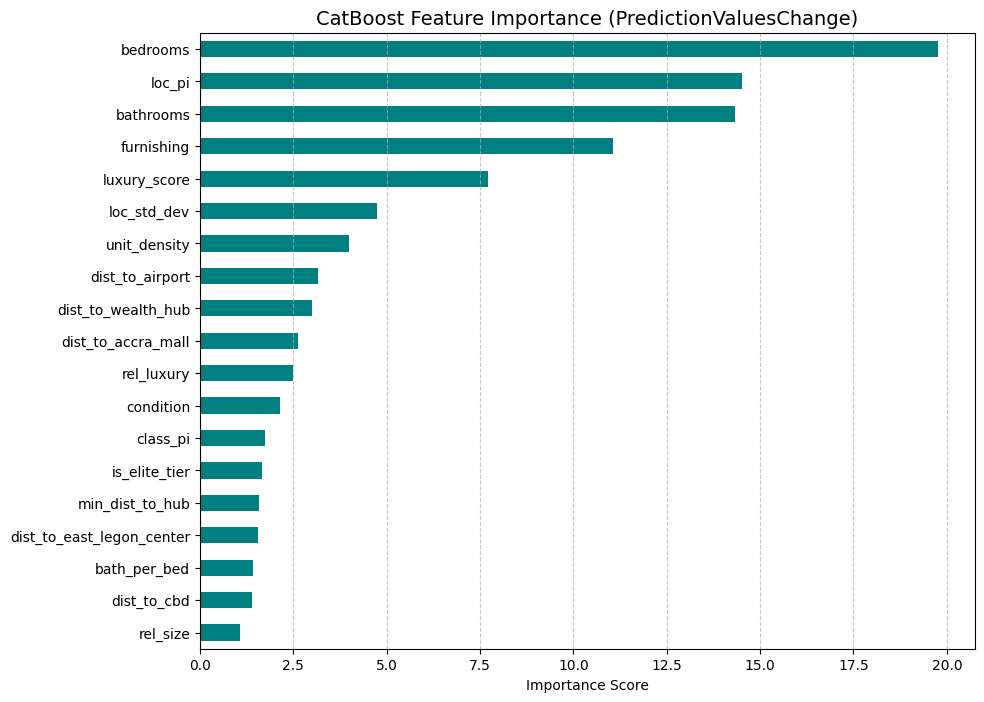

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

feat_importances = pd.Series(
    model.get_feature_importance(), index=X_train.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_importances.tail(20).plot(kind="barh", color="teal")
plt.title("CatBoost Feature Importance (PredictionValuesChange)", fontsize=14)
plt.xlabel("Importance Score")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()
